# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Muhammad Rizkiya Ramadhanoor
- Email: 2311016310018@mhs.ulm.ac.id
- Id Dicoding: muhammad_rizkiyag03

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### Menyiapkan data yang akan diguankan

In [2]:

# 1. Baca data asli
df = pd.read_csv('data.csv', sep=';')

# 2. Buat kolom angka otomatis (1 untuk Dropout, 0 untuk lainnya)
df['Is_Dropout'] = (df['Status'] == 'Dropout').astype(int)

# 3. Simpan ke file CSV baru dengan pemisah koma standar
df.to_csv('data_clean.csv', index=False)
print("File data_clean.csv berhasil dibuat!")

File data_clean.csv berhasil dibuat!


## Data Understanding

/tmp/ipykernel_3499/52388761.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Menunggak (0)', 'Lunas (1)'])
/tmp/ipykernel_3499/52388761.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(['Bukan Penerima (0)', 'Penerima (1)'])


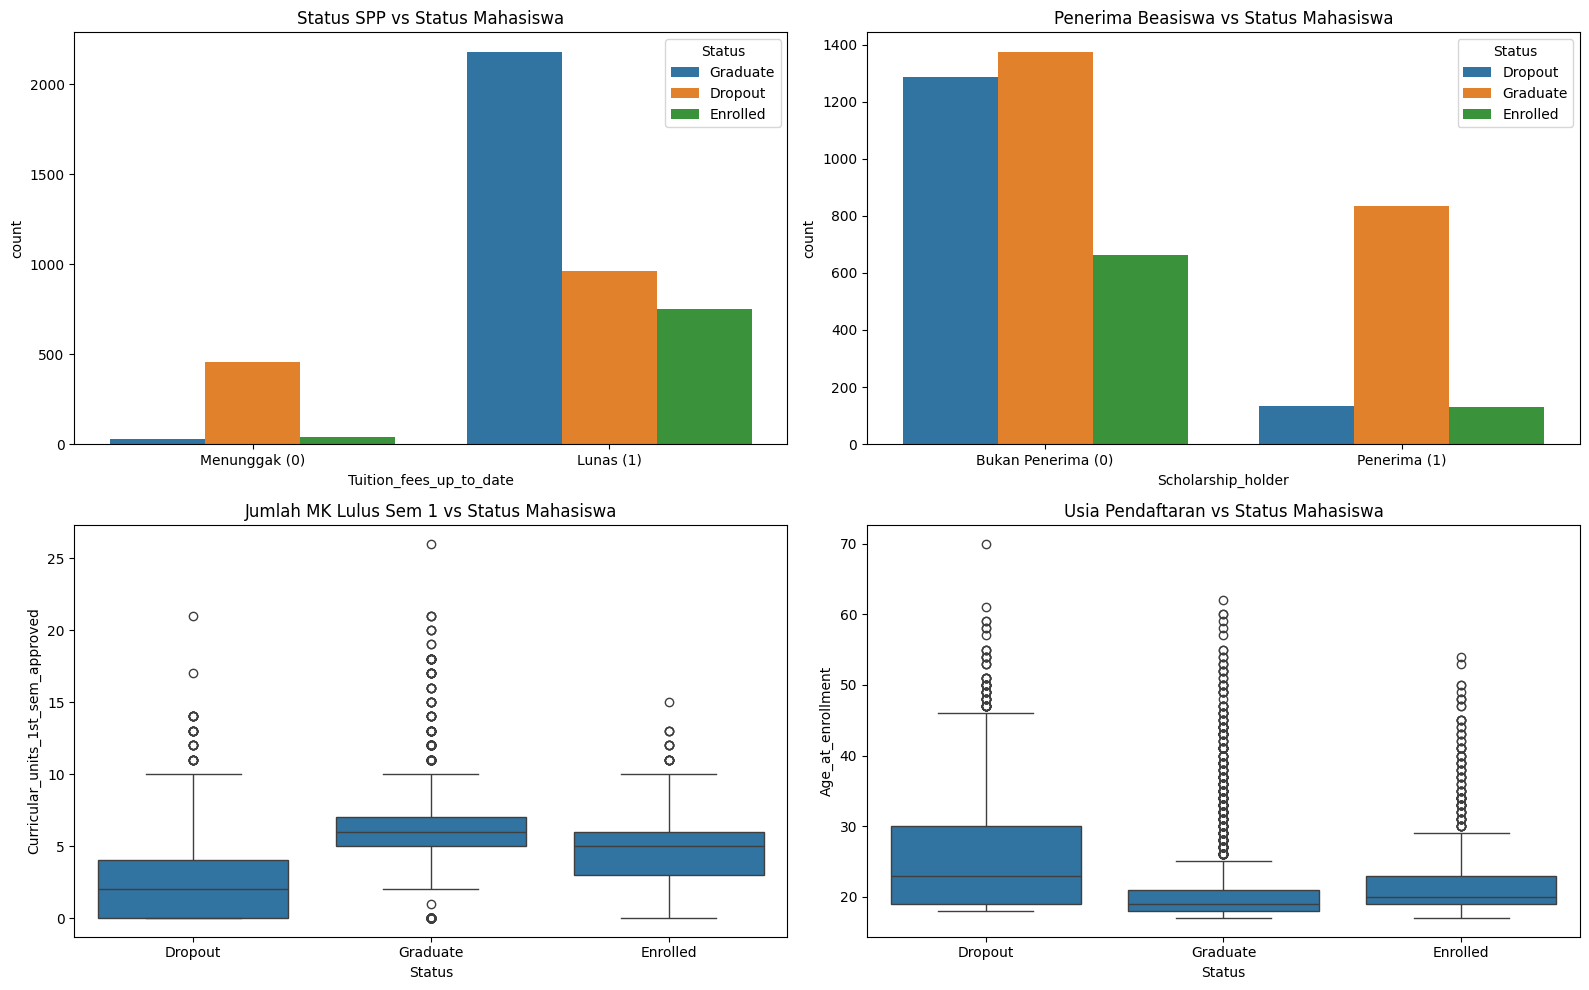

In [3]:
# Visualisasi faktor-faktor utama penyebab Dropout
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Status Kelulusan SPP (Tuition fees up to date) vs Status Mahasiswa
sns.countplot(ax=axes[0, 0], data=df, x='Tuition_fees_up_to_date', hue='Status')
axes[0, 0].set_title('Status SPP vs Status Mahasiswa')
axes[0, 0].set_xticklabels(['Menunggak (0)', 'Lunas (1)'])

# 2. Penerima Beasiswa vs Status Mahasiswa
sns.countplot(ax=axes[0, 1], data=df, x='Scholarship_holder', hue='Status')
axes[0, 1].set_title('Penerima Beasiswa vs Status Mahasiswa')
axes[0, 1].set_xticklabels(['Bukan Penerima (0)', 'Penerima (1)'])

# 3. Mata Kuliah Disetujui Sem 1 vs Status
sns.boxplot(ax=axes[1, 0], data=df, x='Status', y='Curricular_units_1st_sem_approved')
axes[1, 0].set_title('Jumlah MK Lulus Sem 1 vs Status Mahasiswa')

# 4. Umur Saat Mendaftar vs Status
sns.boxplot(ax=axes[1, 1], data=df, x='Status', y='Age_at_enrollment')
axes[1, 1].set_title('Usia Pendaftaran vs Status Mahasiswa')

plt.tight_layout()
plt.show()

## Data Preparation / Preprocessing

In [4]:
from sklearn.model_selection import train_test_split

df_filtered = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()

df_enrolled = df[df['Status'] == 'Enrolled'].copy()

df_filtered['Status'] = df_filtered['Status'].map({'Graduate': 0, 'Dropout': 1})

X = df_filtered.drop(columns=['Status', 'Is_Dropout'], errors='ignore')
y = df_filtered['Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Total Data Pemodelan: {df_filtered.shape[0]} baris")
print(f"Total Data Enrolled (Dipisahkan): {df_enrolled.shape[0]} baris")
print(f"Data Latih: {X_train.shape[0]} baris | Data Uji: {X_test.shape[0]} baris")

Total Data Pemodelan: 3630 baris
Total Data Enrolled (Dipisahkan): 794 baris
Data Latih: 2904 baris | Data Uji: 726 baris


## Modeling

In [5]:
# Menginisialisasi dan melatih model Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Membuat folder 'model' (jika belum ada) dan menyimpan file model.joblib
os.makedirs('model', exist_ok=True)
joblib.dump(model, 'model/model.joblib')

print("Model berhasil dilatih dan disimpan ke 'model/model.joblib'!")

Model berhasil dilatih dan disimpan ke 'model/model.joblib'!


## Evaluation

Akurasi Model: 92.15%

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.94       442
           1       0.92      0.88      0.90       284

    accuracy                           0.92       726
   macro avg       0.92      0.91      0.92       726
weighted avg       0.92      0.92      0.92       726



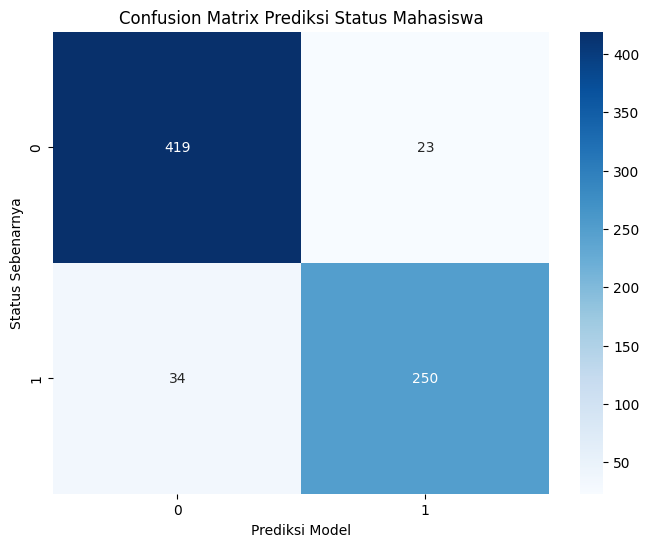

In [6]:
# Melakukan prediksi pada data uji
y_pred = model.predict(X_test)

# Menampilkan nilai Akurasi dan Laporan Klasifikasi
print(f"Akurasi Model: {accuracy_score(y_test, y_pred):.2%}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix Prediksi Status Mahasiswa')
plt.xlabel('Prediksi Model')
plt.ylabel('Status Sebenarnya')
plt.show()